Using device: cuda
Train size: 144174
Val size: 23741
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]



========== Epoch 1/7 ==========


100%|██████████| 2253/2253 [35:57<00:00,  1.04it/s]


Train Loss: 0.2740 | Val Loss: 0.2506
✅ Best model saved

========== Epoch 2/7 ==========


...

Train Loss: 0.1084 | Val Loss: 0.2332

========== Epoch 7/7 ==========


100%|██████████| 2253/2253 [23:04<00:00,  1.63it/s]


Train Loss: 0.0956 | Val Loss: 0.2399

Training Complete

Evaluating...


100%|██████████| 371/371 [02:38<00:00,  2.35it/s]



========== FINAL RESULTS ==========
Precision: 0.8795641060137226
Recall: 0.8509879467888475
Micro F1: 0.8650400910317817
Macro F1: 0.8516806892524376


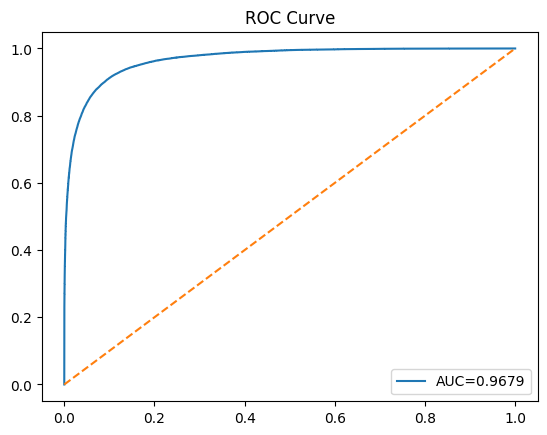

In [1]:
# ============================================================
# RESNET50 TRANSFER + FINE-TUNING (FINAL CLEAN VERSION)
# ============================================================

import os, json, torch, numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc

# ================= DEVICE =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================= PATHS =================
BASE_PATH = "/kaggle/input/datasets/iharshsinha/deepfashion2-top5-processed/processed"

TRAIN_IMG = os.path.join(BASE_PATH, "train/images")
TRAIN_ANN = os.path.join(BASE_PATH, "train/annos")

VAL_IMG   = os.path.join(BASE_PATH, "validation/images")
VAL_ANN   = os.path.join(BASE_PATH, "validation/annos")

# ================= LABEL MAP =================
LABEL_MAP = {
    "short sleeve top": 0,
    "long sleeve top": 1,
    "shorts": 2,
    "trousers": 3,
    "skirt": 4
}
NUM_CLASSES = 5

# ================= DATASET =================
class DeepFashionDataset(Dataset):

    def __init__(self, img_dir, ann_dir, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.files = os.listdir(ann_dir)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        file = self.files[idx]
        json_path = os.path.join(self.ann_dir, file)
        img_path = os.path.join(self.img_dir, file.replace(".json", ".jpg"))

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            return torch.zeros((3,224,224)), torch.zeros(NUM_CLASSES)

        if self.transform:
            image = self.transform(image)

        with open(json_path) as f:
            data = json.load(f)

        target = torch.zeros(NUM_CLASSES)

        for key, val in data.items():
            if key.startswith("item"):
                cat = val["category_name"]
                if cat in LABEL_MAP:
                    target[LABEL_MAP[cat]] = 1.0

        return image, target

# ================= TRANSFORMS =================
train_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ================= DATA =================
train_dataset = DeepFashionDataset(TRAIN_IMG, TRAIN_ANN, train_tf)
val_dataset   = DeepFashionDataset(VAL_IMG, VAL_ANN, val_tf)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

# ================= MODEL =================
model = models.resnet50(weights=ResNet50_Weights.DEFAULT)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace FC
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

# ================= LOSS =================
criterion = nn.BCEWithLogitsLoss()

# Initial optimizer (only partial layers)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# ================= TRAIN =================
epochs = 7
best_val_loss = float("inf")

for epoch in range(epochs):

    print(f"\n========== Epoch {epoch+1}/{epochs} ==========")

    # 🔥 FINE-TUNING PHASE START
    if epoch == 4:
        print("\n🔥 Starting FULL FINE-TUNING...")

        for param in model.parameters():
            param.requires_grad = True

        optimizer = optim.Adam(model.parameters(), lr=1e-4)

    # -------- TRAIN --------
    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/kaggle/working/resnet_best.pth")
        print("✅ Best model saved")

# Save final
torch.save(model.state_dict(), "/kaggle/working/resnet_last.pth")

print("\nTraining Complete")

# ================= EVALUATION =================
print("\nEvaluating...")

model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader):

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

precision = precision_score(all_labels, all_preds, average='micro')
recall = recall_score(all_labels, all_preds, average='micro')
micro_f1 = f1_score(all_labels, all_preds, average='micro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')

print("\n========== FINAL RESULTS ==========")
print("Precision:", precision)
print("Recall:", recall)
print("Micro F1:", micro_f1)
print("Macro F1:", macro_f1)

# ROC
fpr, tpr, _ = roc_curve(all_labels.ravel(), all_probs.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")

plt.savefig("/kaggle/working/resnet_roc.png")
plt.show()